# Supplementary Material S1: Reproducible Analysis Notebook (v2.0)

**Article:** A Five-Step Multi-Dimensional Learnability Validation Protocol for Meningitis Clinical Risk Assessment
**Authors:** Fathimah Al-Ma'shumah, Yasi Dani, Yani Triyani, Dani Suandi

This notebook runs the single analysis pipeline of the repository and reproduces every table and figure of
the article. All rules (positive classes, step thresholds, Step 5 reference directions, model settings) are
defined once in `src/config.py`; each validation step is implemented once in `src/protocol.py`.

| Article item | Produced by |
|---|---|
| Table 1, Fig. 3 | repeated stratified cross-validation |
| Table 2, Fig. 4 | class-wise metrics of the representative model (LightGBM) |
| Table 3, Figs. 5-6 | calibration and decision curves, mortality (Deceased = positive) |
| Table 4 | Step 5 sign audit against the literature reference |
| Table 5 | five-step verdict and ablation |
| Figs. 1-2, 7-9 | workflow, correlation matrix, SHAP, integer score |

Environment: see `requirements.txt` (XGBoost 2.0 series). Seeds are fixed at 42.

In [1]:
import sys, json, pandas as pd
sys.path.insert(0, 'src')
import config as C
print({k: getattr(C, k) for k in ['TAU','MI_THRESHOLD','DCA_RANGE','NB_MARGIN','S5_MIN_SHARE','POSITIVE','REPRESENTATIVE']})
print('Step 5 reference:', json.dumps(C.S5_REFERENCE, indent=1))

{'TAU': 0.1, 'MI_THRESHOLD': 0.05, 'DCA_RANGE': (0.05, 0.5), 'NB_MARGIN': 0.01, 'S5_MIN_SHARE': 0.7, 'POSITIVE': {'Diagnosis': 'Bacterial', 'Outcome': 'Deceased', 'Risk_Level': 'High Risk'}, 'REPRESENTATIVE': 'LightGBM'}
Step 5 reference: {
 "Diagnosis": {
  "WBC_Count": 1,
  "Protein_Level": 1,
  "Glucose_Level": -1,
  "WBC_Blood_Count": 1,
  "CRP_Level": 1
 },
 "Risk_Level": {
  "WBC_Count": 1,
  "Protein_Level": 1,
  "Glucose_Level": -1,
  "WBC_Blood_Count": 1,
  "CRP_Level": 1
 },
 "Outcome": {
  "Age": 1,
  "WBC_Count": -1,
  "Glucose_Level": -1,
  "Pathogen_Present": 1,
  "CRP_Level": 1
 }
}


## 1. Run every analysis (about 5 minutes)

In [2]:
%run src/run_all.py

CV done Diagnosis


CV done Outcome


CV done Risk_Level


steps done Diagnosis {'S1': True, 'S2': True, 'S3': True, 'S4': True, 'S5': True}


steps done Outcome {'S1': False, 'S2': False, 'S3': False, 'S4': False, 'S5': False}


steps done Risk_Level {'S1': True, 'S2': True, 'S3': True, 'S4': True, 'S5': True}
{
 "Diagnosis": [
  {
   "S1": true,
   "S2": true,
   "S3": true,
   "S4": true,
   "S5": true
  },
  "passes"
 ],
 "Outcome": [
  {
   "S1": false,
   "S2": false,
   "S3": false,
   "S4": false,
   "S5": false
  },
  "does not pass"
 ],
 "Risk_Level": [
  {
   "S1": true,
   "S2": true,
   "S3": true,
   "S4": true,
   "S5": true
  },
  "passes"
 ]
}
ablation {'without_S1': [], 'without_S2': [], 'without_S3': [], 'without_S4': [], 'without_S5': [], 'only_S1': [], 'only_S2': [], 'only_S3': [], 'only_S4': [], 'only_S5': [], 'discrimination_only': ['Outcome'], 'discrimination_only_any_model': ['Outcome']}


In [3]:
R = json.load(open('results/results.json'))
pd.DataFrame(R['step1']).T

,max_abs_r,argmax_r,max_abs_rho,max_mi,argmax_mi,pass
Diagnosis,0.840262,Pathogen_Present,0.840154,0.564336,CRP_Level,True
Outcome,0.06717,WBC_Count,0.065152,0.012649,CRP_Level,False
Risk_Level,0.511468,Pathogen_Present,0.570151,0.482299,Glucose_Level,True


## 2. Table 1: discrimination under repeated stratified cross-validation

In [4]:
rows = []
for t, v in R['cv'].items():
    for m, d in v.items():
        rows.append({'target': C.TARGET_NAME[t], 'model': m, 'AUC': f"{d['auc']:.3f} ± {d['auc_sd']:.3f}", 'MCC': f"{d['mcc']:.3f} ± {d['mcc_sd']:.3f}", 'macro-F1': f"{d['f1']:.3f} ± {d['f1_sd']:.3f}"})
pd.DataFrame(rows)

,target,model,AUC,MCC,macro-F1
0,Diagnosis,LR,0.907 ± 0.021,0.739 ± 0.028,0.702 ± 0.023
1,Diagnosis,RF,0.969 ± 0.007,0.790 ± 0.027,0.721 ± 0.037
2,Diagnosis,LightGBM,0.970 ± 0.007,0.793 ± 0.025,0.708 ± 0.037
3,Diagnosis,CatBoost,0.970 ± 0.007,0.780 ± 0.029,0.684 ± 0.038
4,Diagnosis,XGBoost,0.971 ± 0.007,0.787 ± 0.028,0.699 ± 0.040
5,Mortality,LR,0.541 ± 0.042,0.035 ± 0.056,0.430 ± 0.024
6,Mortality,RF,0.523 ± 0.058,0.007 ± 0.065,0.502 ± 0.032
7,Mortality,LightGBM,0.525 ± 0.062,0.013 ± 0.064,0.505 ± 0.031
8,Mortality,CatBoost,0.522 ± 0.055,0.010 ± 0.060,0.504 ± 0.030
9,Mortality,XGBoost,0.522 ± 0.068,0.009 ± 0.055,0.503 ± 0.027


## 3. Table 2: class-wise metrics, LightGBM, held-out test fold

In [5]:
rows = []
for t, v in R['classwise'].items():
    for i, lab in enumerate(v['labels']):
        rows.append({'target': C.TARGET_NAME[t], 'class': lab, 'precision': round(v['precision'][i],3), 'recall': round(v['recall'][i],3), 'F1': round(v['f1'][i],3), 'support': v['support'][i]})
pd.DataFrame(rows)

,target,class,precision,recall,F1,support
0,Diagnosis,Bacterial,0.898,0.970,0.933,100
1,Diagnosis,Unknown,0.200,0.091,0.125,11
2,Diagnosis,Viral,0.925,0.899,0.912,69
3,Mortality,Deceased,0.045,0.053,0.049,19
4,Mortality,Recovered,0.886,0.870,0.878,161
5,Risk level,High Risk,0.948,0.910,0.929,100
6,Risk level,Low Risk,0.880,0.943,0.910,70
7,Risk level,Moderate Risk,0.333,0.300,0.316,10


## 4. Table 3: Brier decomposition, mortality (Deceased = positive class)

In [6]:
pd.DataFrame(R['brier_mortality']).T.round(4)

,BS,REL,RES,UNC,BS_minus_UNC,BSS
LR,0.2322,0.1398,0.0024,0.0944,0.1378,-1.4598
RF,0.1499,0.0533,0.0005,0.0944,0.0555,-0.5873
LightGBM,0.1762,0.0822,0.0046,0.0944,0.0818,-0.8661
CatBoost,0.1493,0.0574,0.0041,0.0944,0.0549,-0.5813
XGBoost,0.1673,0.0724,0.0020,0.0944,0.0729,-0.7724
LGBM-Cal,0.0949,0.0051,0.0046,0.0944,0.0004,-0.0047


## 5. Table 4: Step 5 sign audit

In [7]:
rows = []
for t, s in R['steps'].items():
    for a in s['S5']['audit']:
        rows.append({'target': C.TARGET_NAME[t], 'feature': a['feature'], 'expected': a['expected'], 'coefficient': round(a['fitted_coef'],3), 'agrees': a['agrees']})
pd.DataFrame(rows)

,target,feature,expected,coefficient,agrees
0,Diagnosis,WBC_Count,1,0.397,True
1,Diagnosis,Protein_Level,1,-0.001,False
2,Diagnosis,Glucose_Level,-1,-0.427,True
3,Diagnosis,WBC_Blood_Count,1,0.273,True
4,Diagnosis,CRP_Level,1,0.688,True
5,Mortality,Age,1,0.015,True
6,Mortality,WBC_Count,-1,-0.195,True
7,Mortality,Glucose_Level,-1,0.062,False
8,Mortality,Pathogen_Present,1,-0.684,False
9,Mortality,CRP_Level,1,-0.156,False


## 6. Table 5: five-step verdict and ablation

In [8]:
pd.DataFrame({C.TARGET_NAME[t]: {**s['flags'], 'verdict': s['verdict']} for t, s in R['steps'].items()})

,Diagnosis,Mortality,Risk level
S1,True,False,True
S2,True,False,True
S3,True,False,True
S4,True,False,True
S5,True,False,True
verdict,passes,does not pass,passes


In [9]:
R['ablation']

{'without_S1': [],
 'without_S2': [],
 'without_S3': [],
 'without_S4': [],
 'without_S5': [],
 'only_S1': [],
 'only_S2': [],
 'only_S3': [],
 'only_S4': [],
 'only_S5': [],
 'discrimination_only': ['Outcome'],
 'discrimination_only_any_model': ['Outcome']}

## 7. Figures 1-9 at print size

done fig1


done fig2


done fig3


done fig4


done fig5


done fig6


done fig7


done fig8


done fig9
figures/fig1_workflow.png


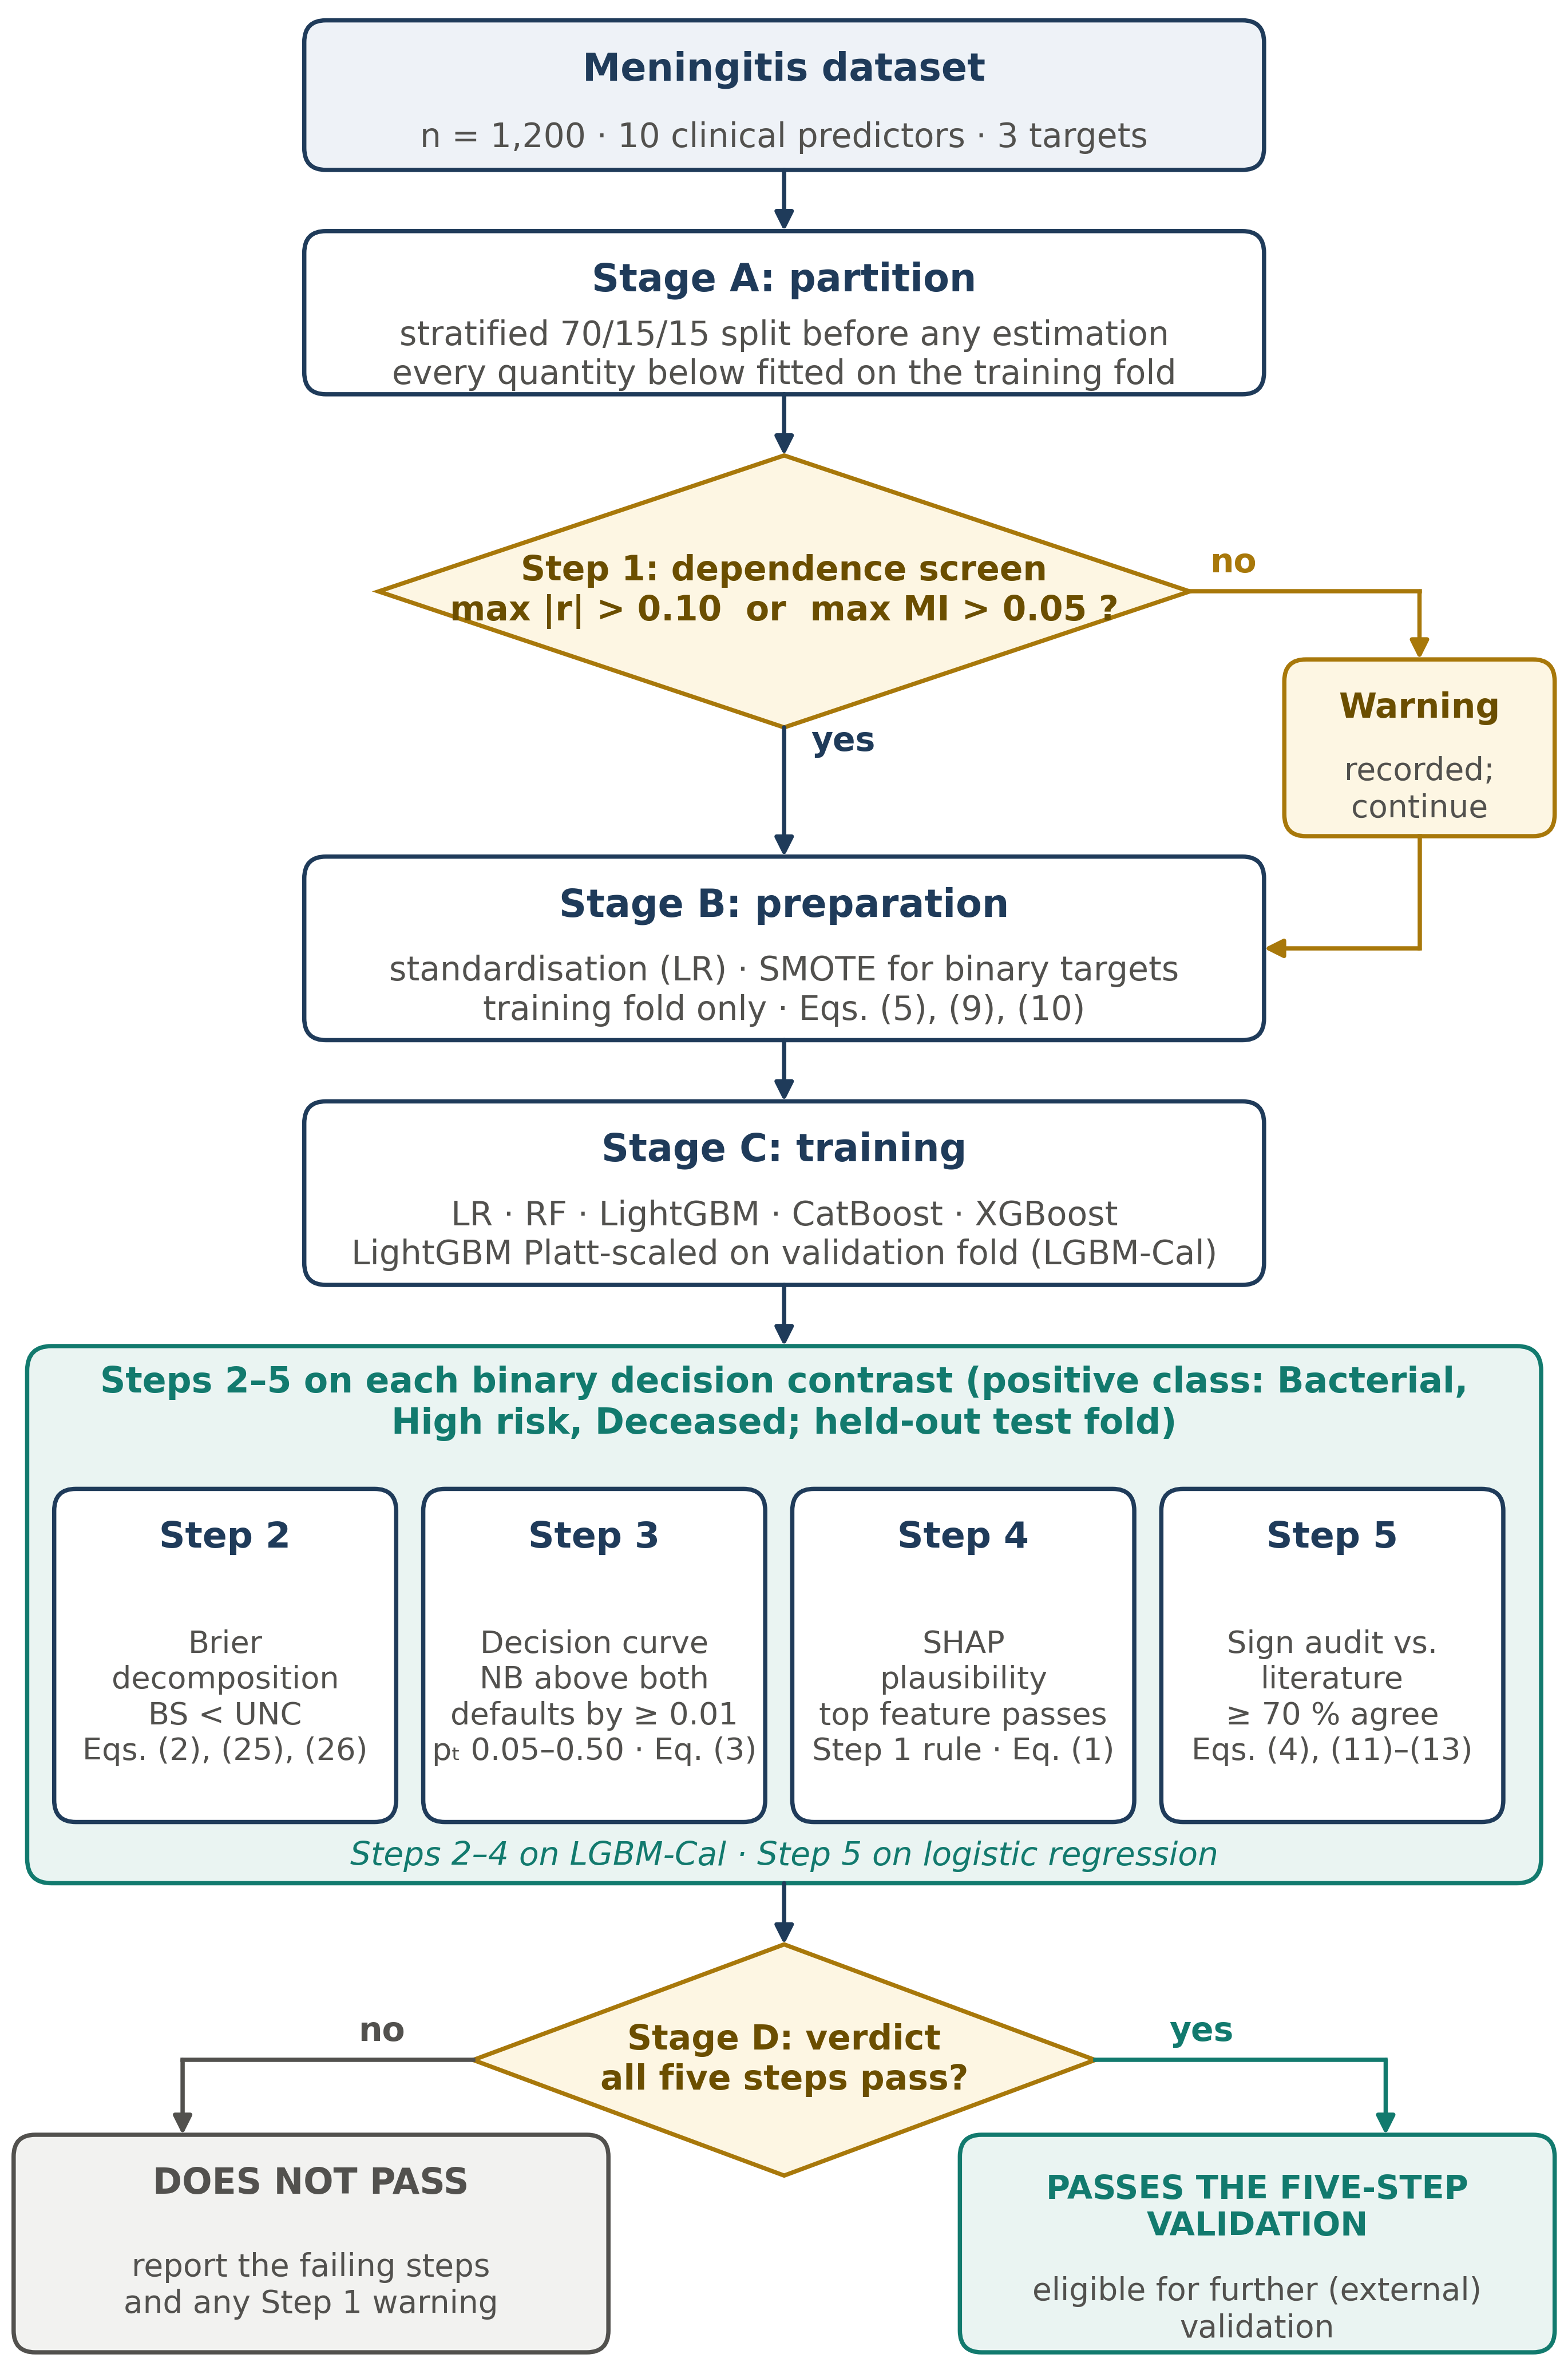

figures/fig2_correlation.png


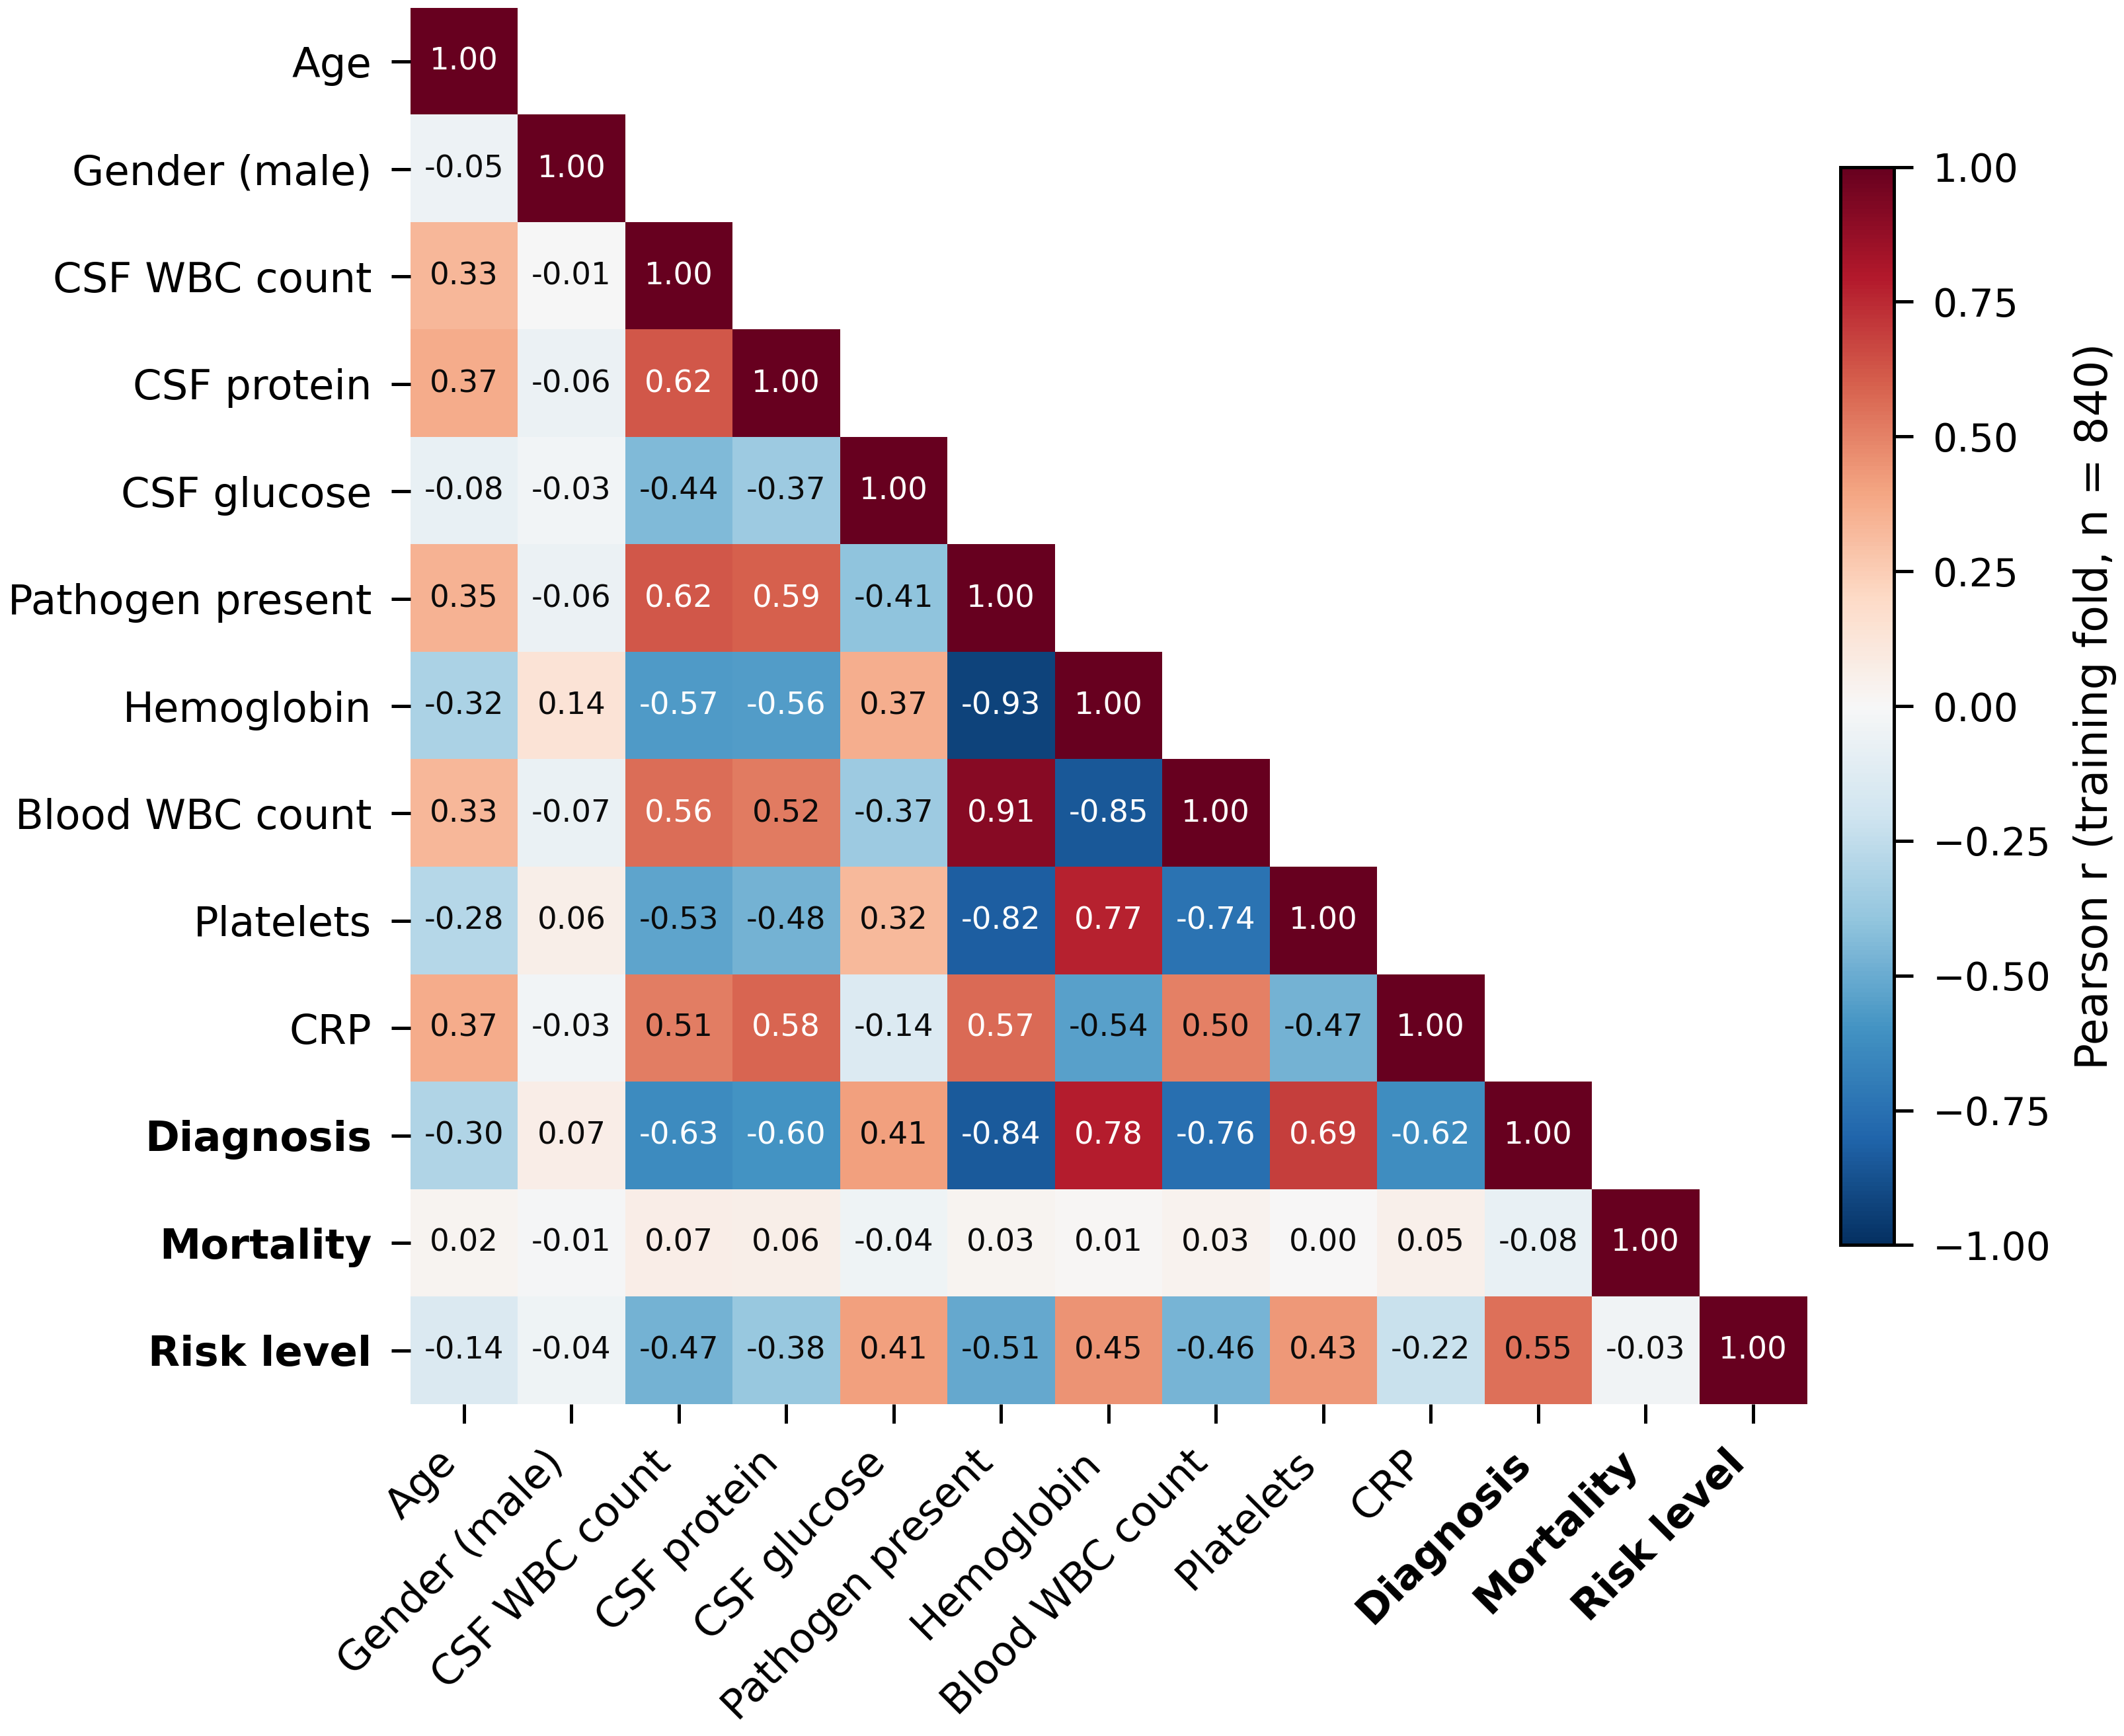

figures/fig3_cv.png


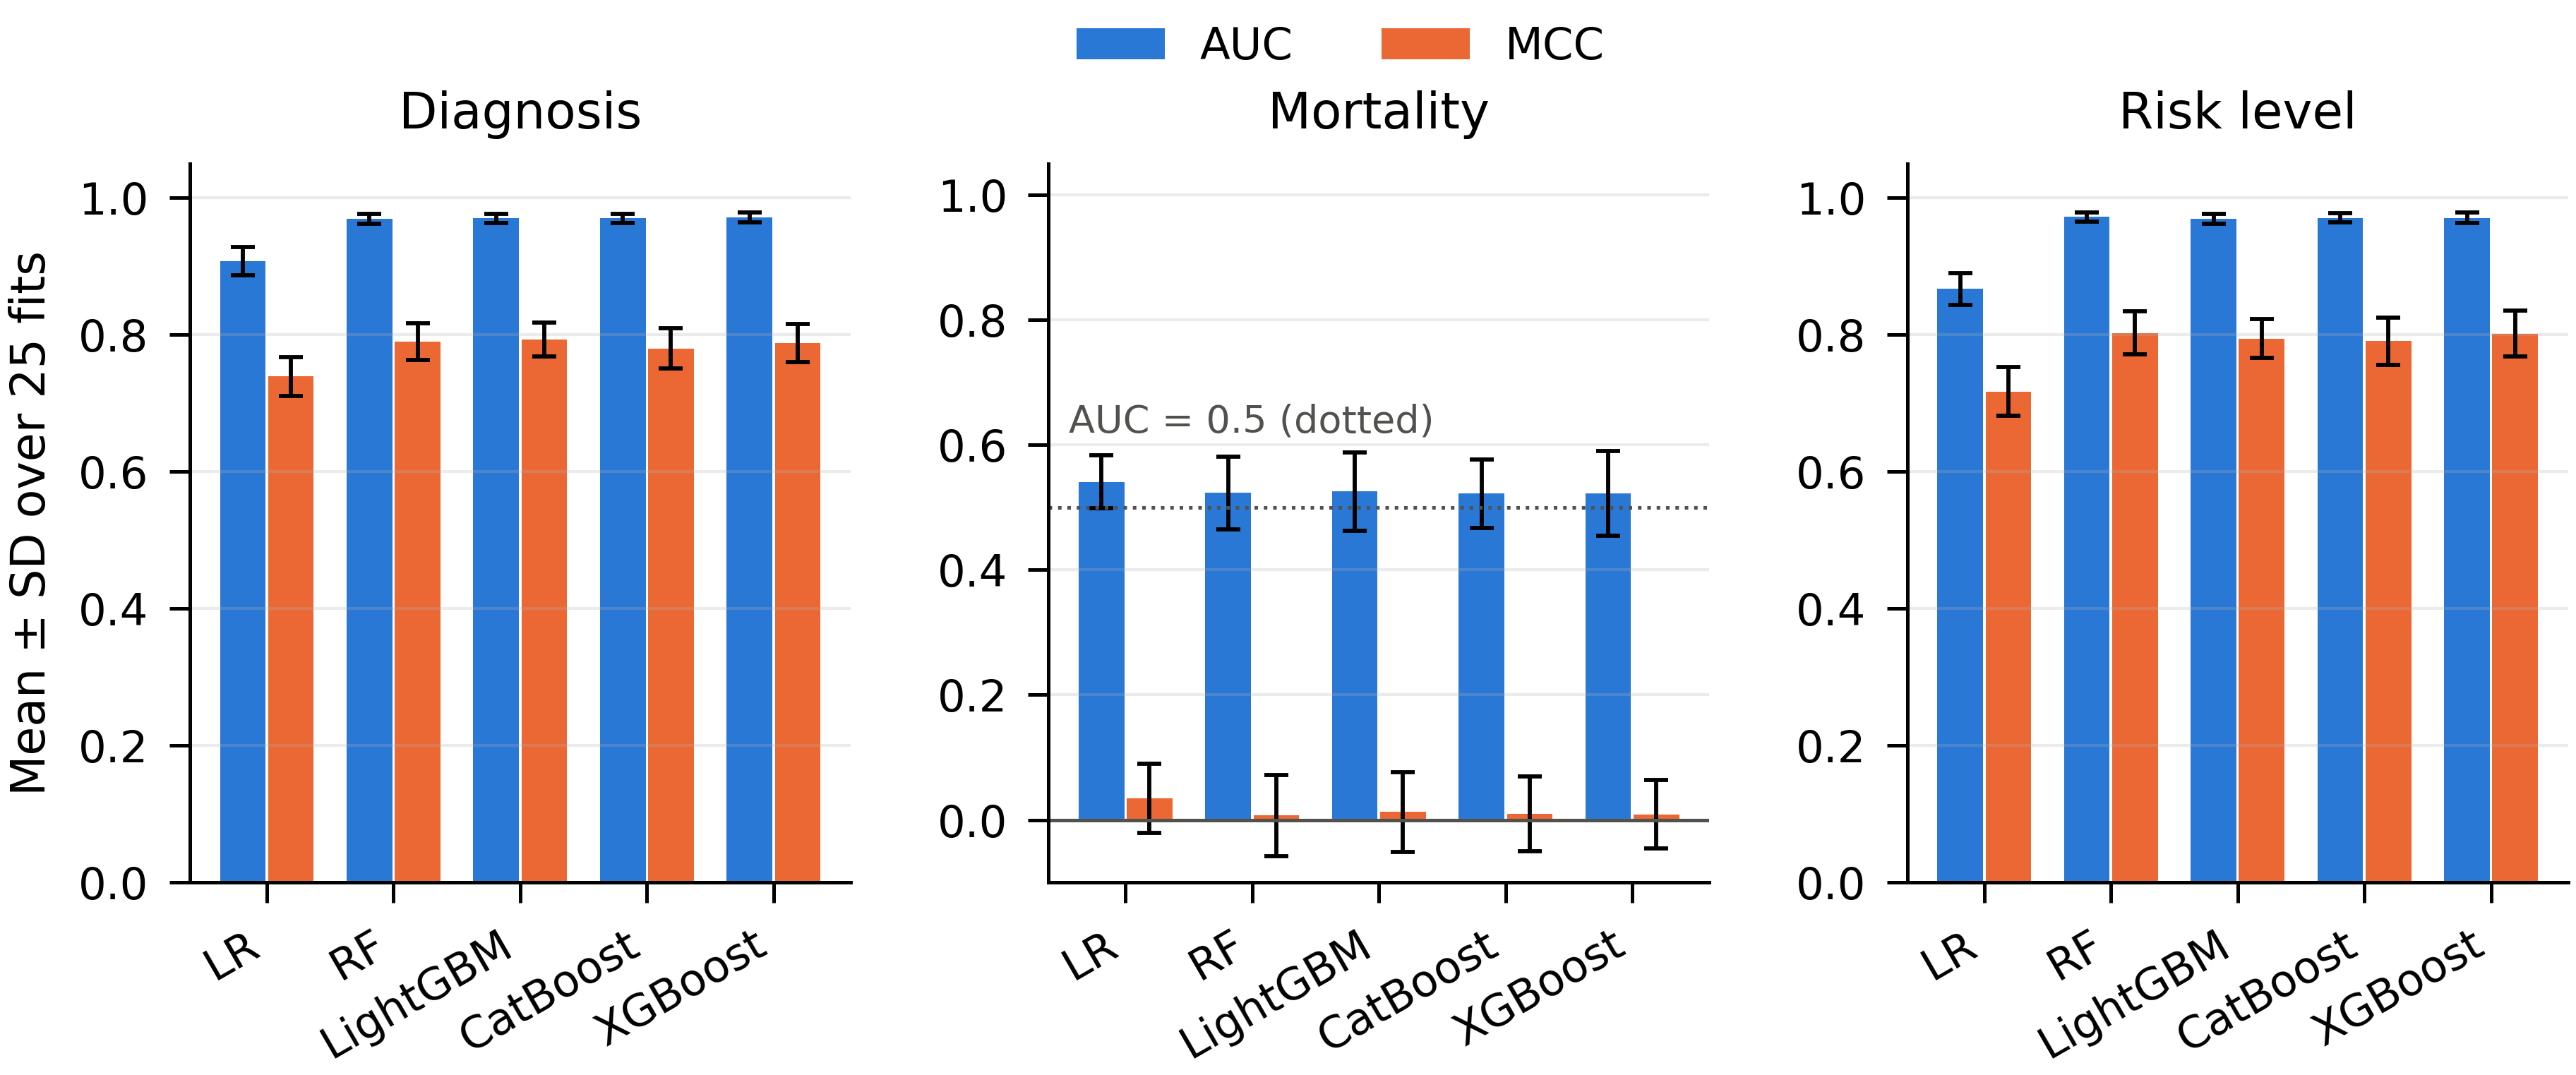

figures/fig4_confusion.png


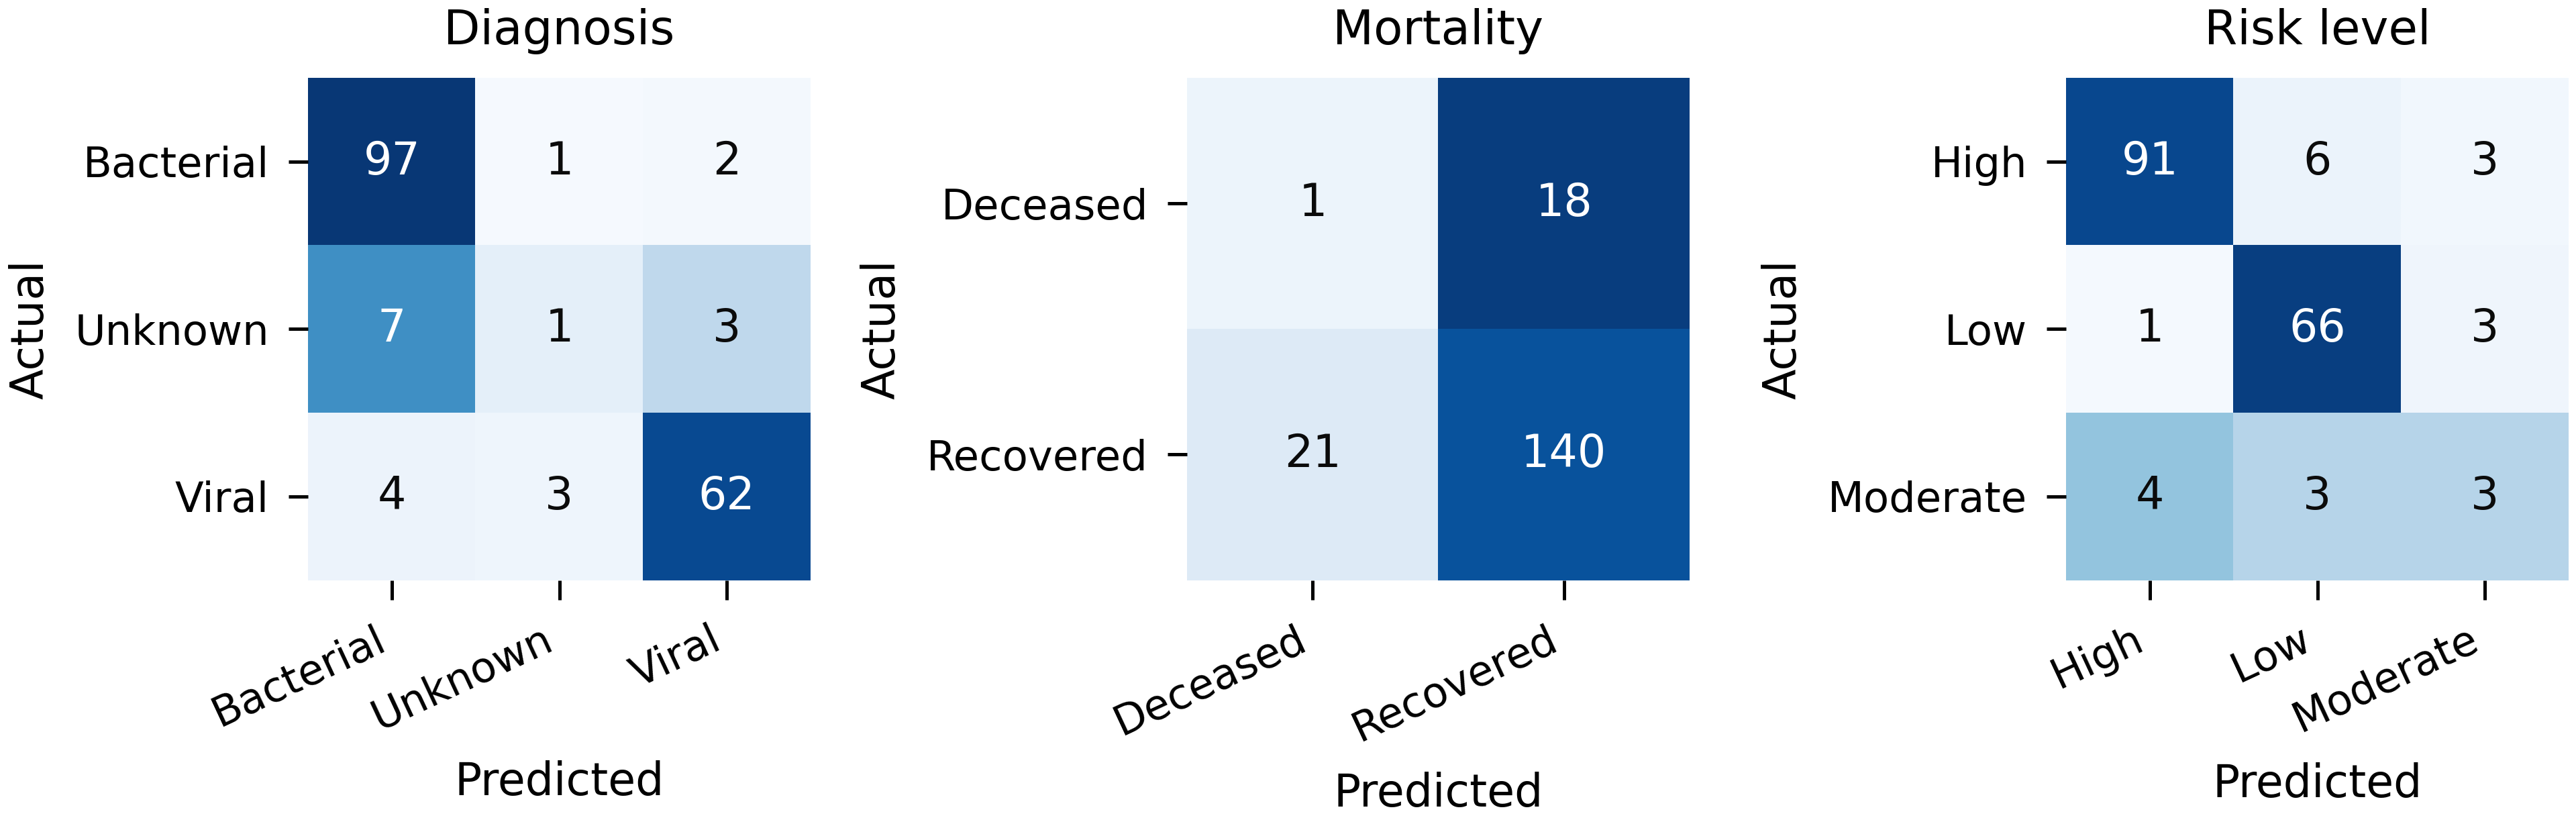

figures/fig5_calibration.png


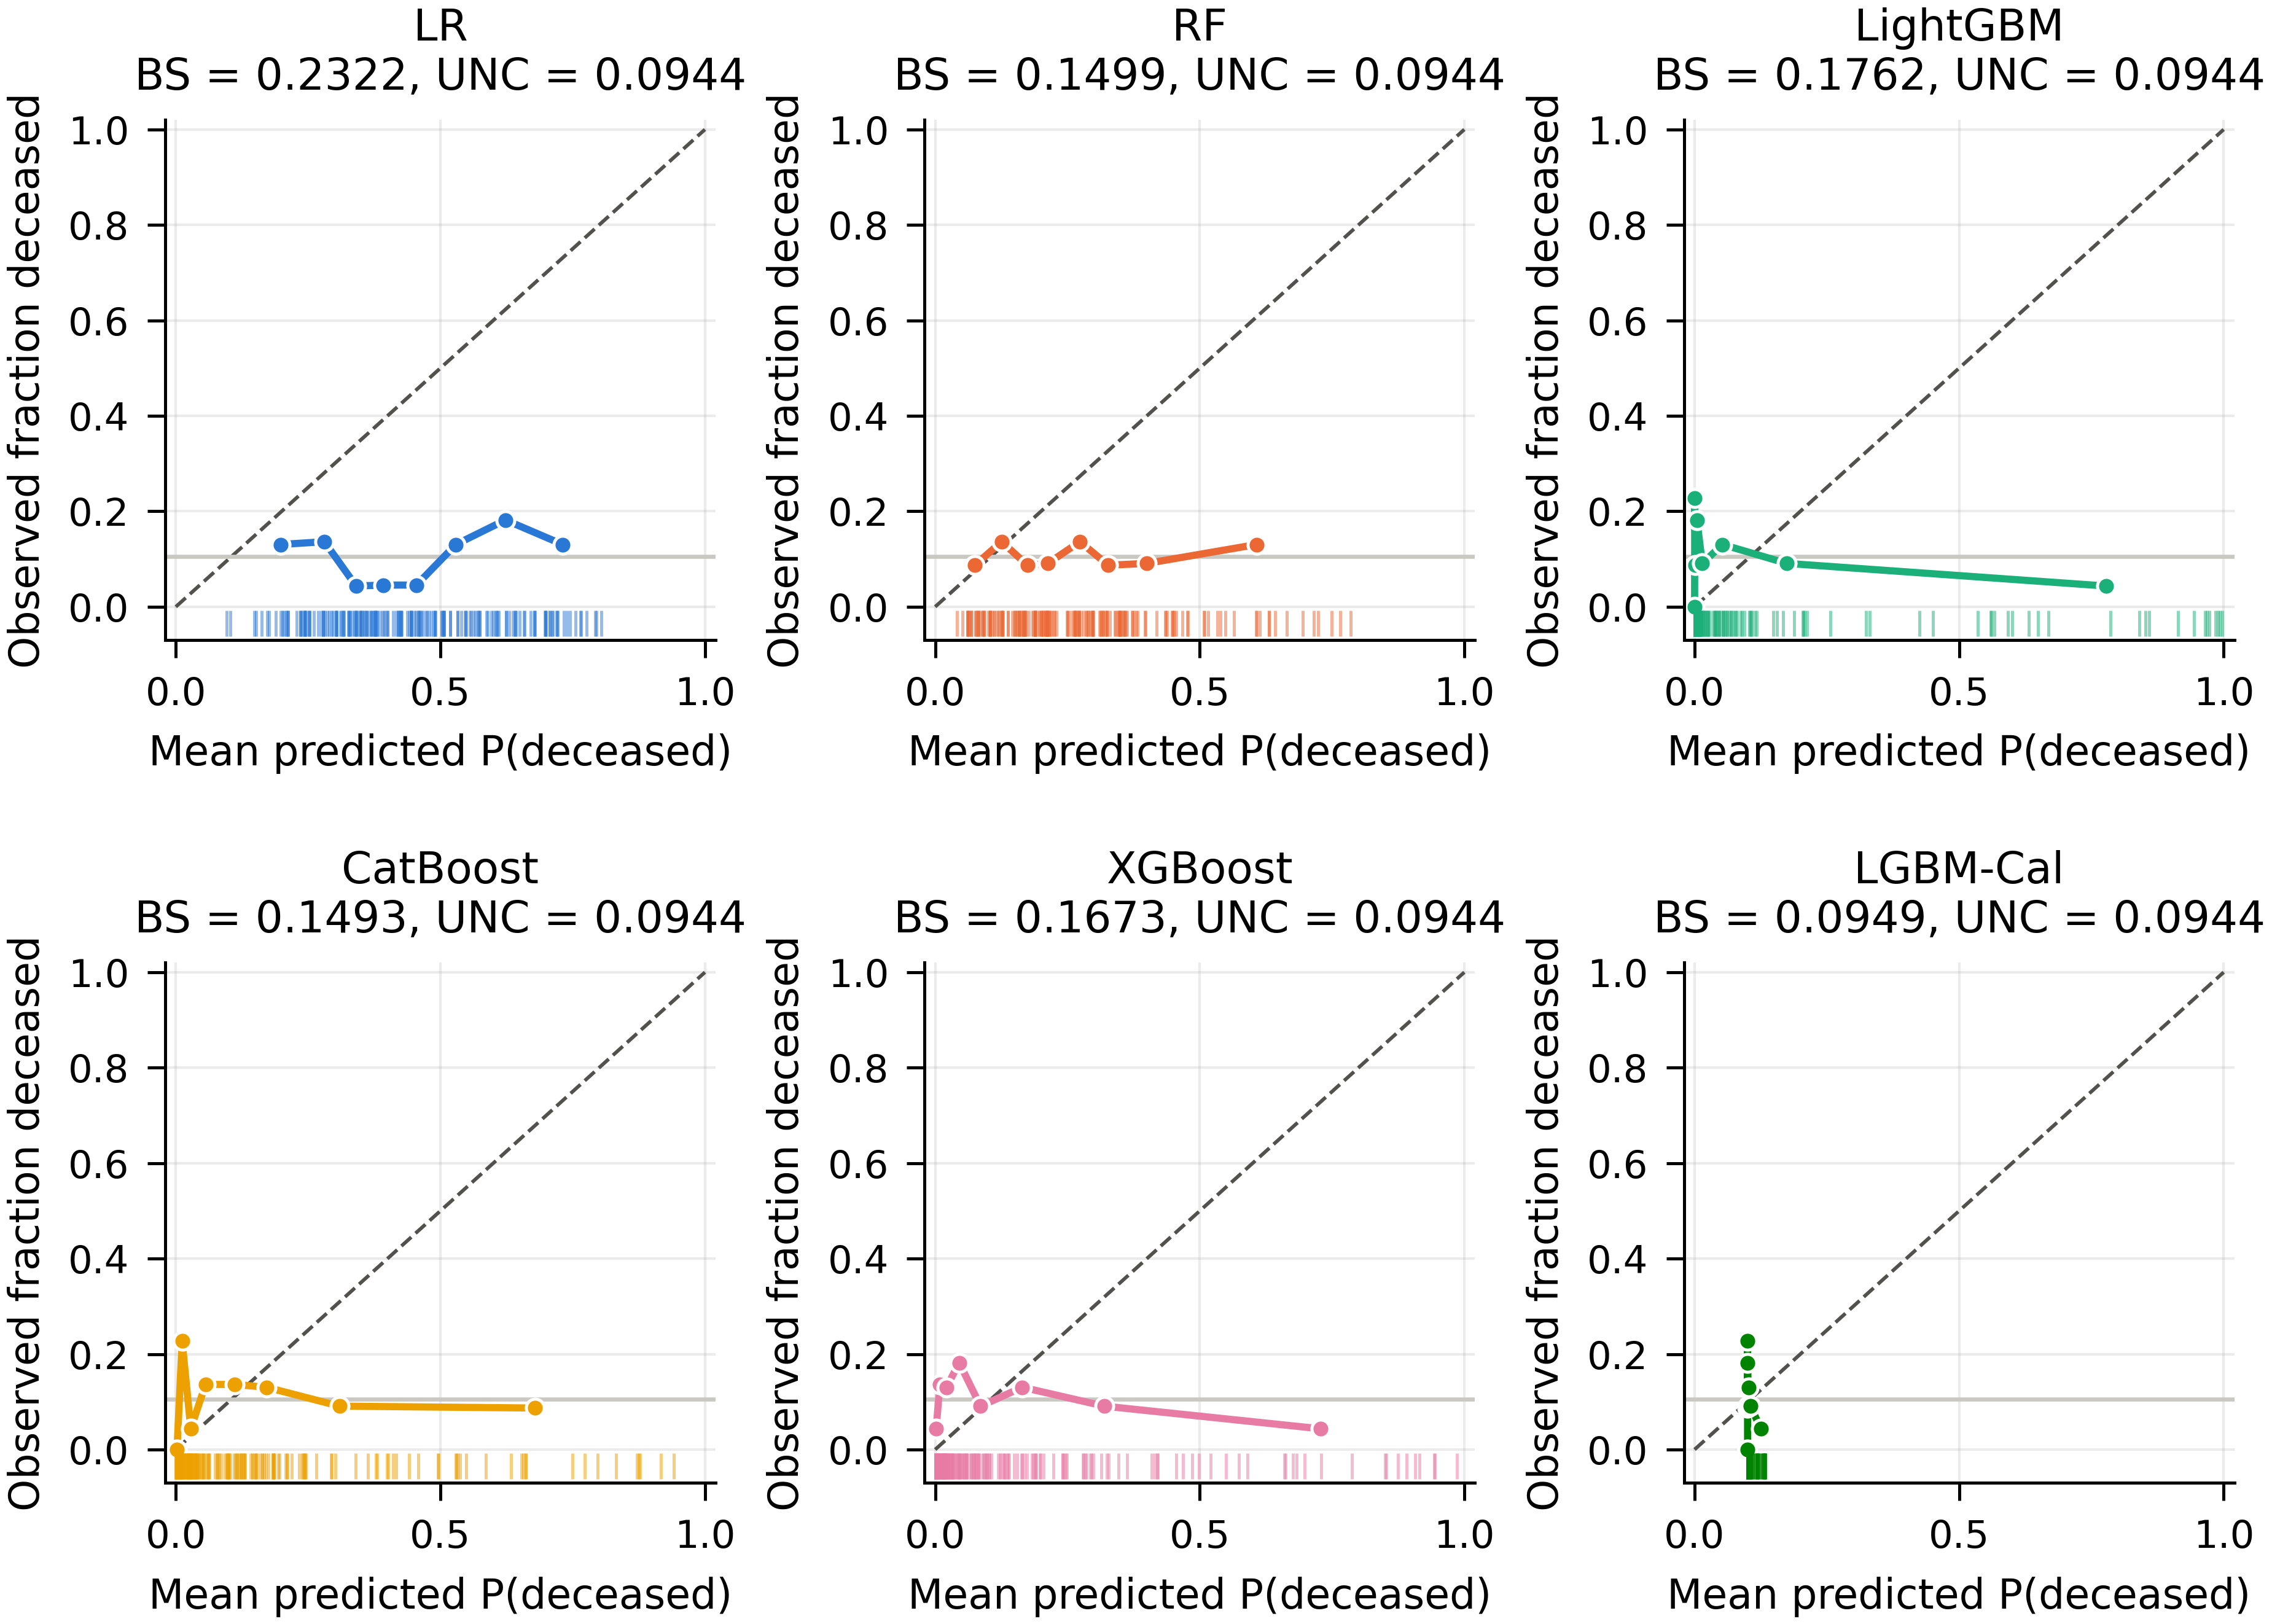

figures/fig6_dca.png


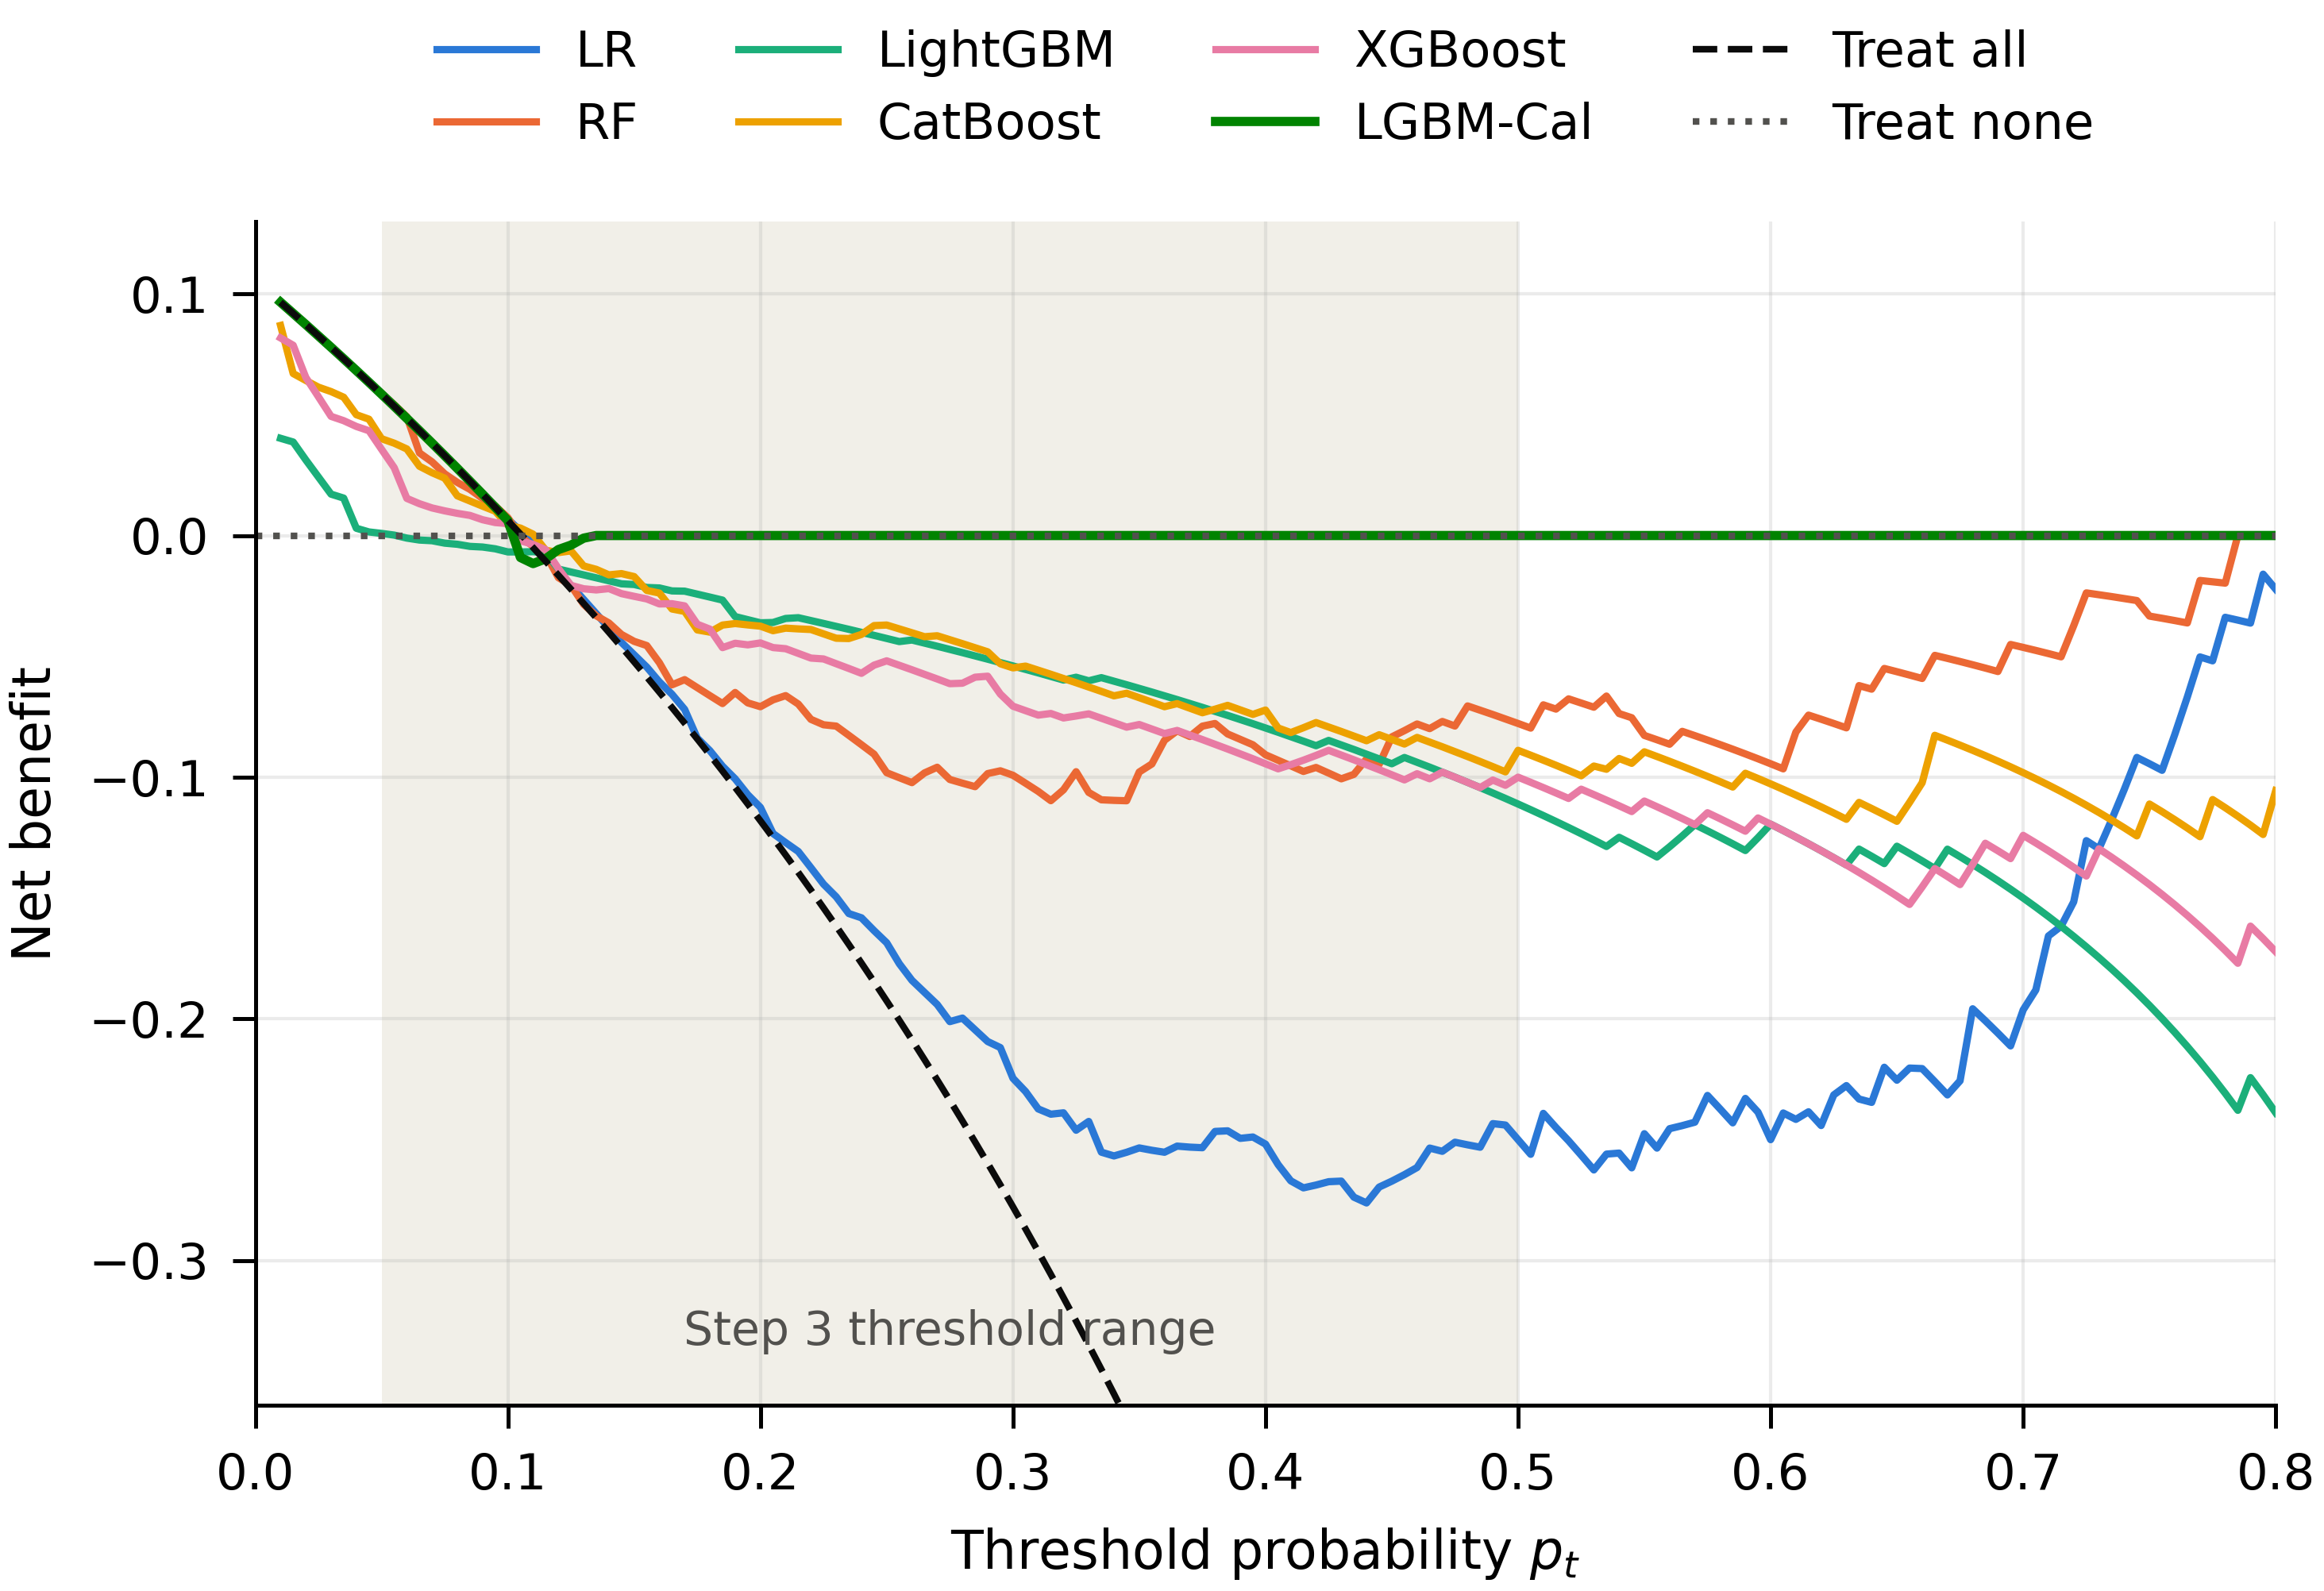

figures/fig7_shap_global.png


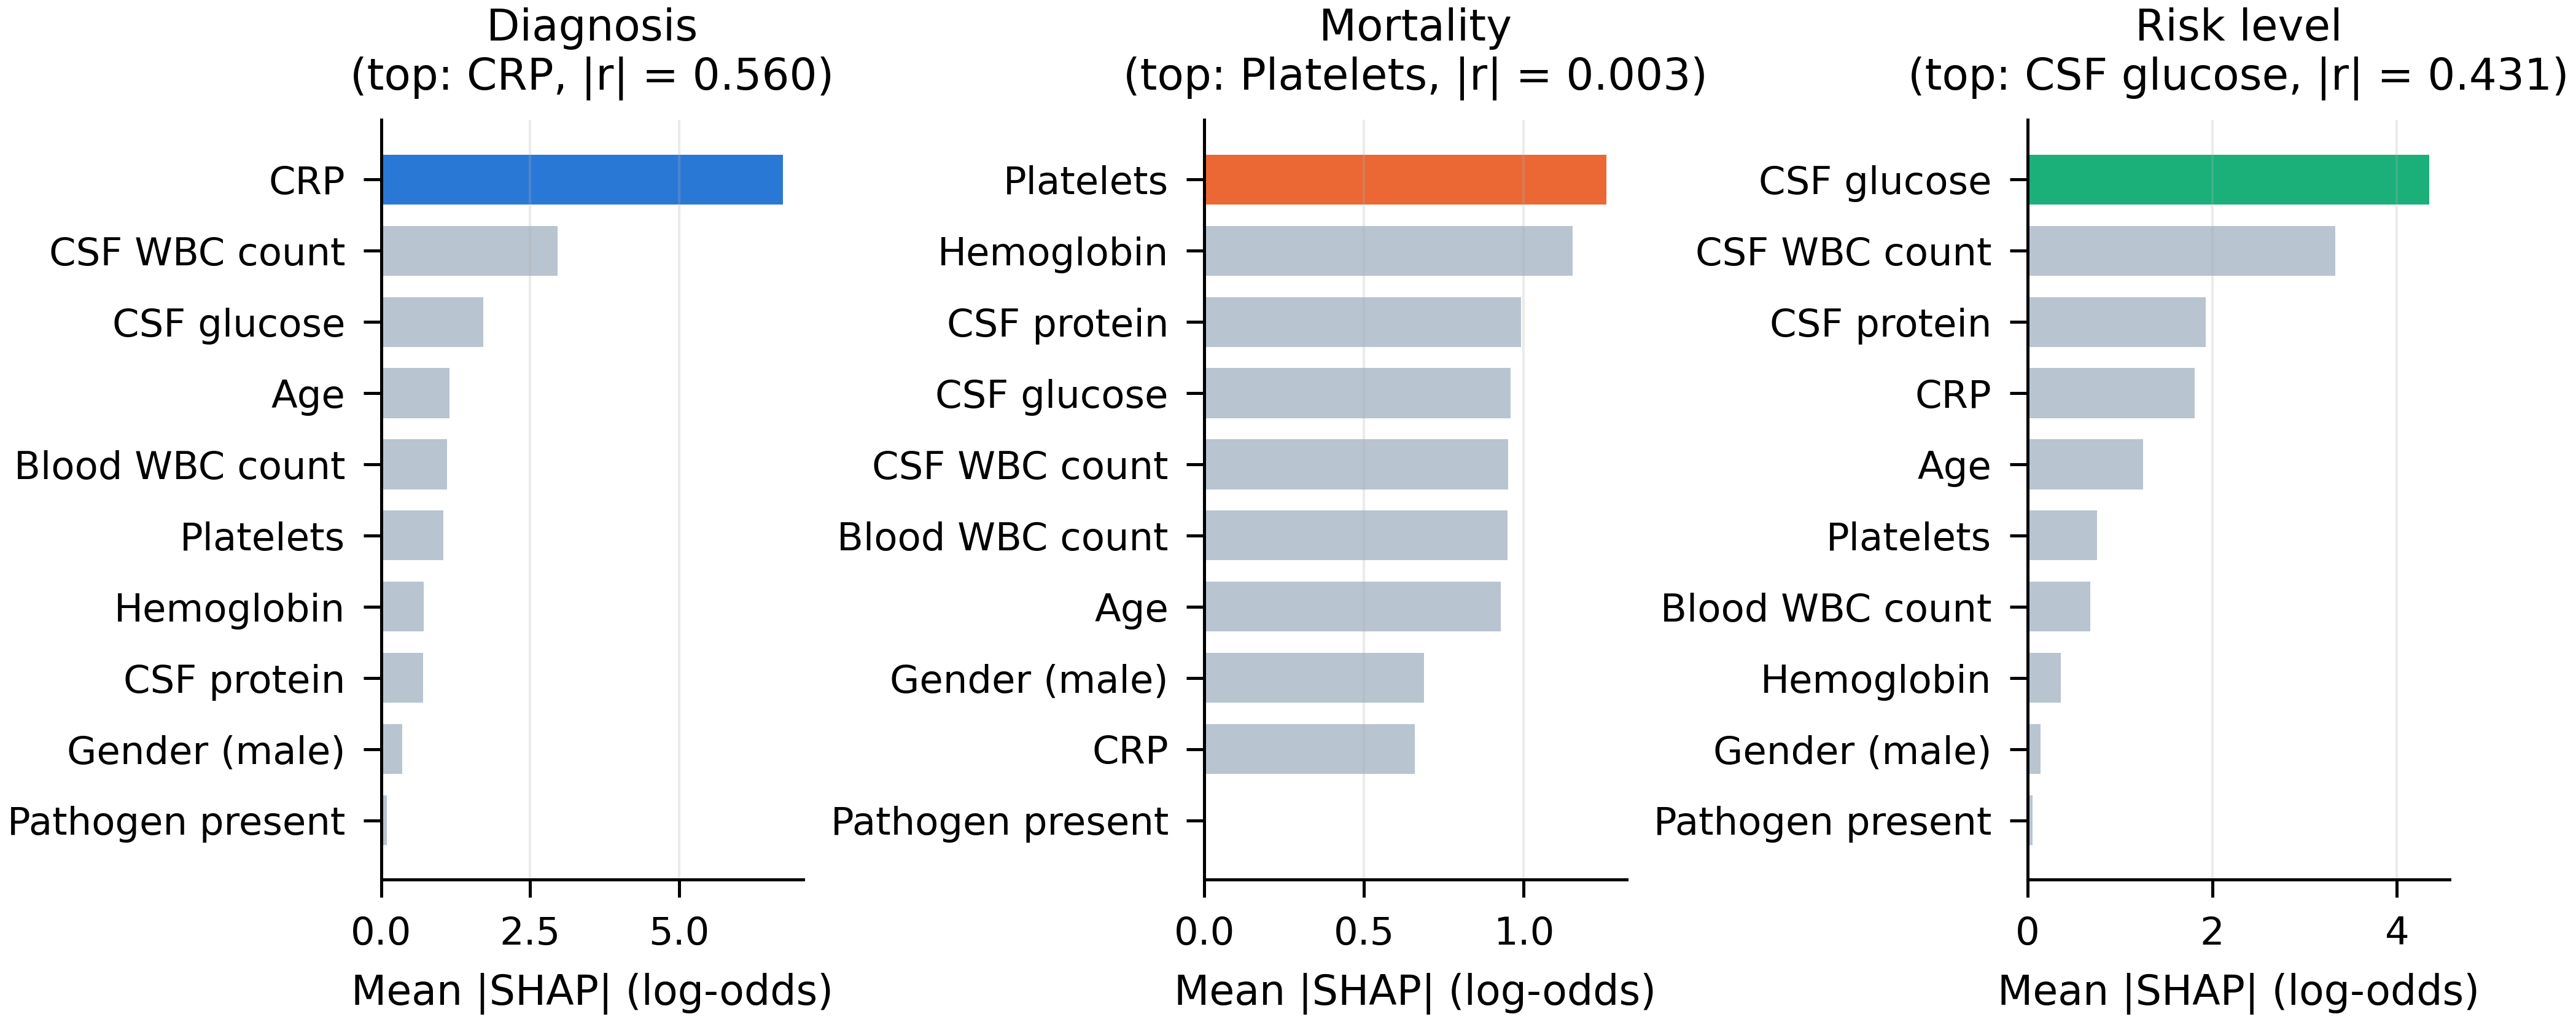

figures/fig8_shap_local.png


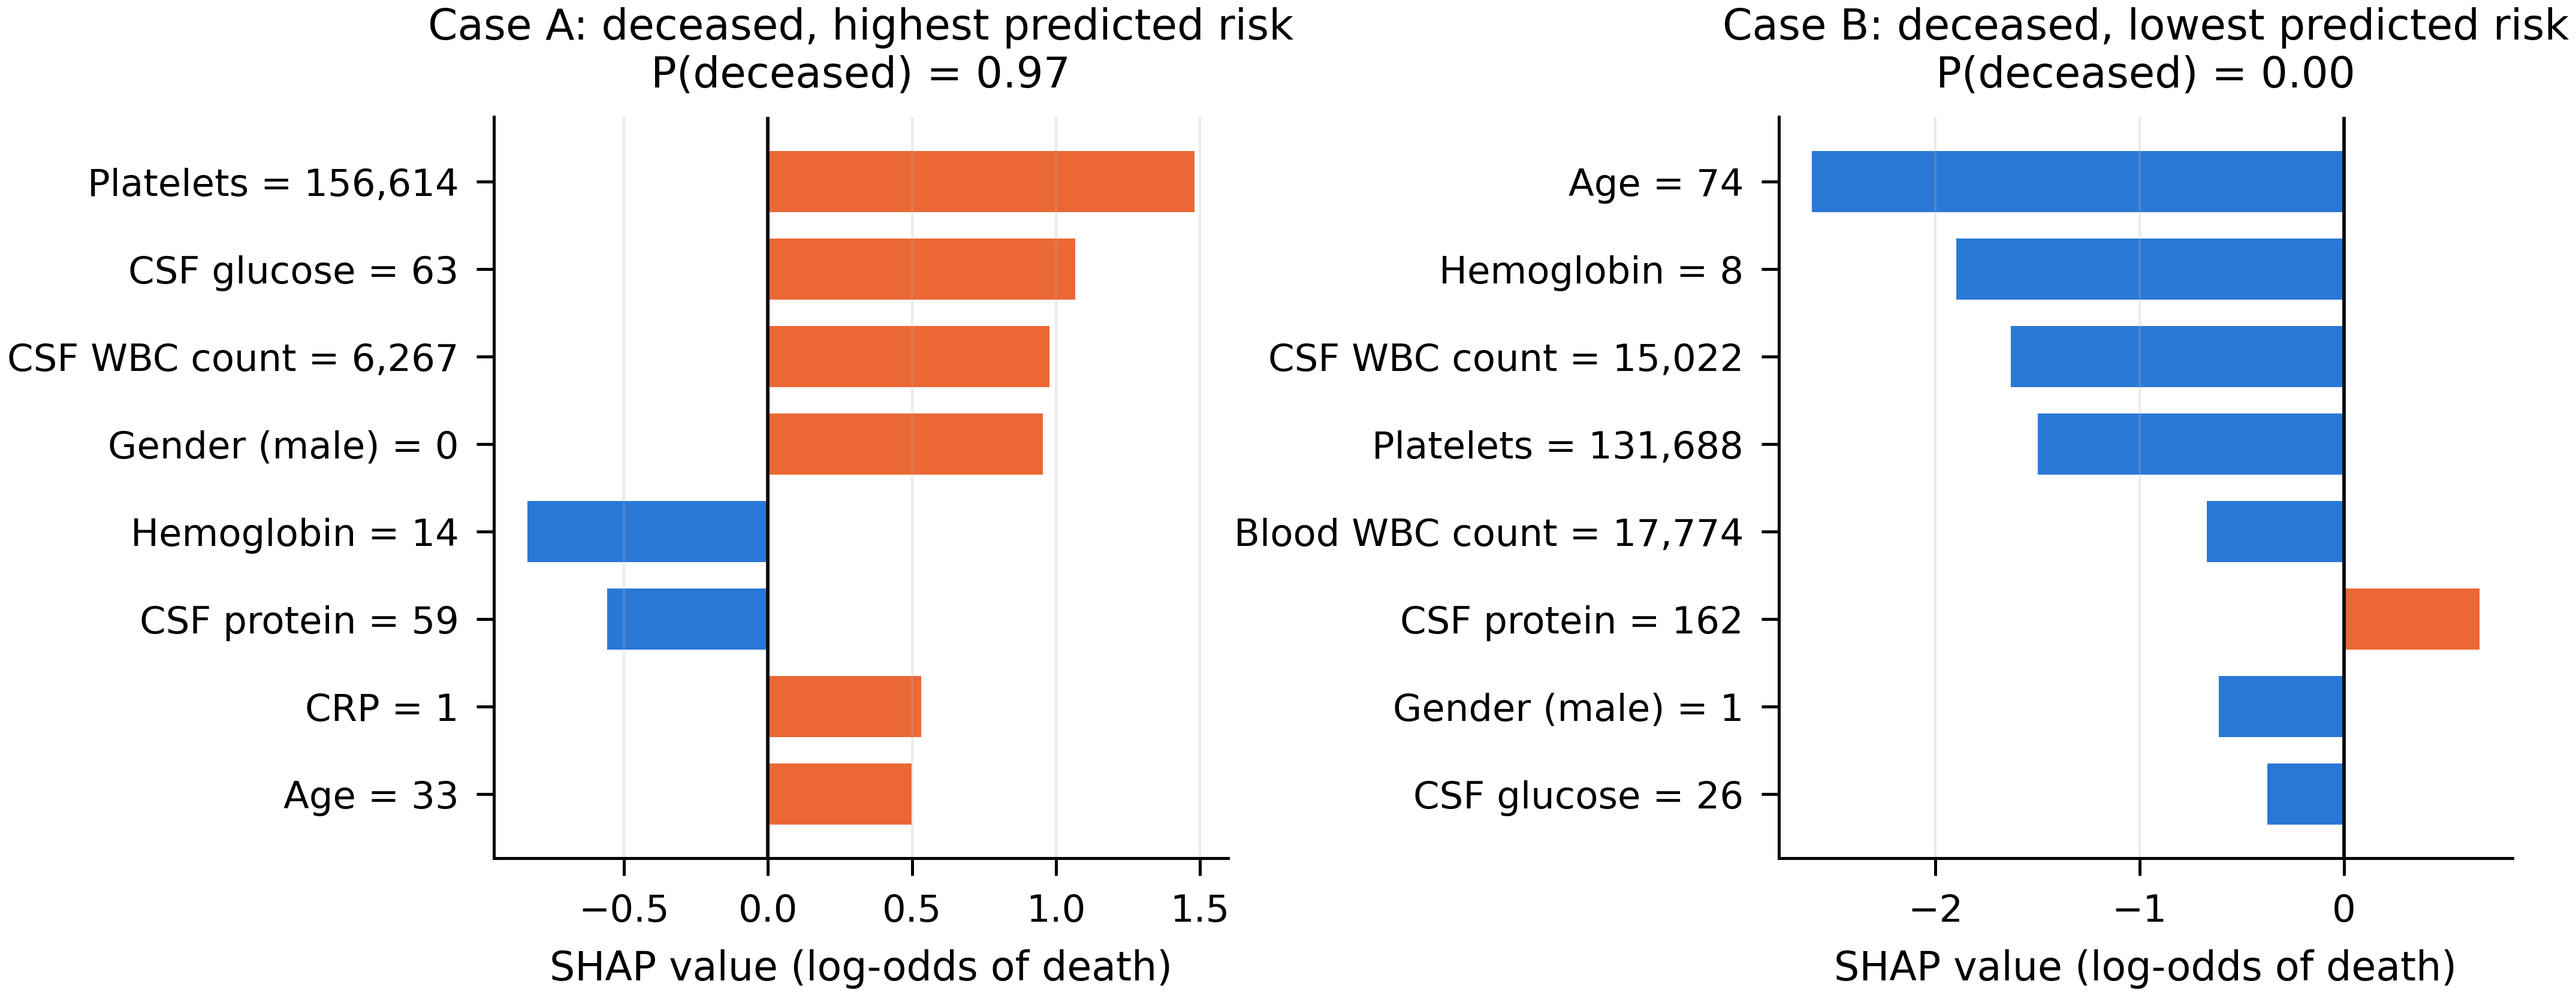

figures/fig9_score.png


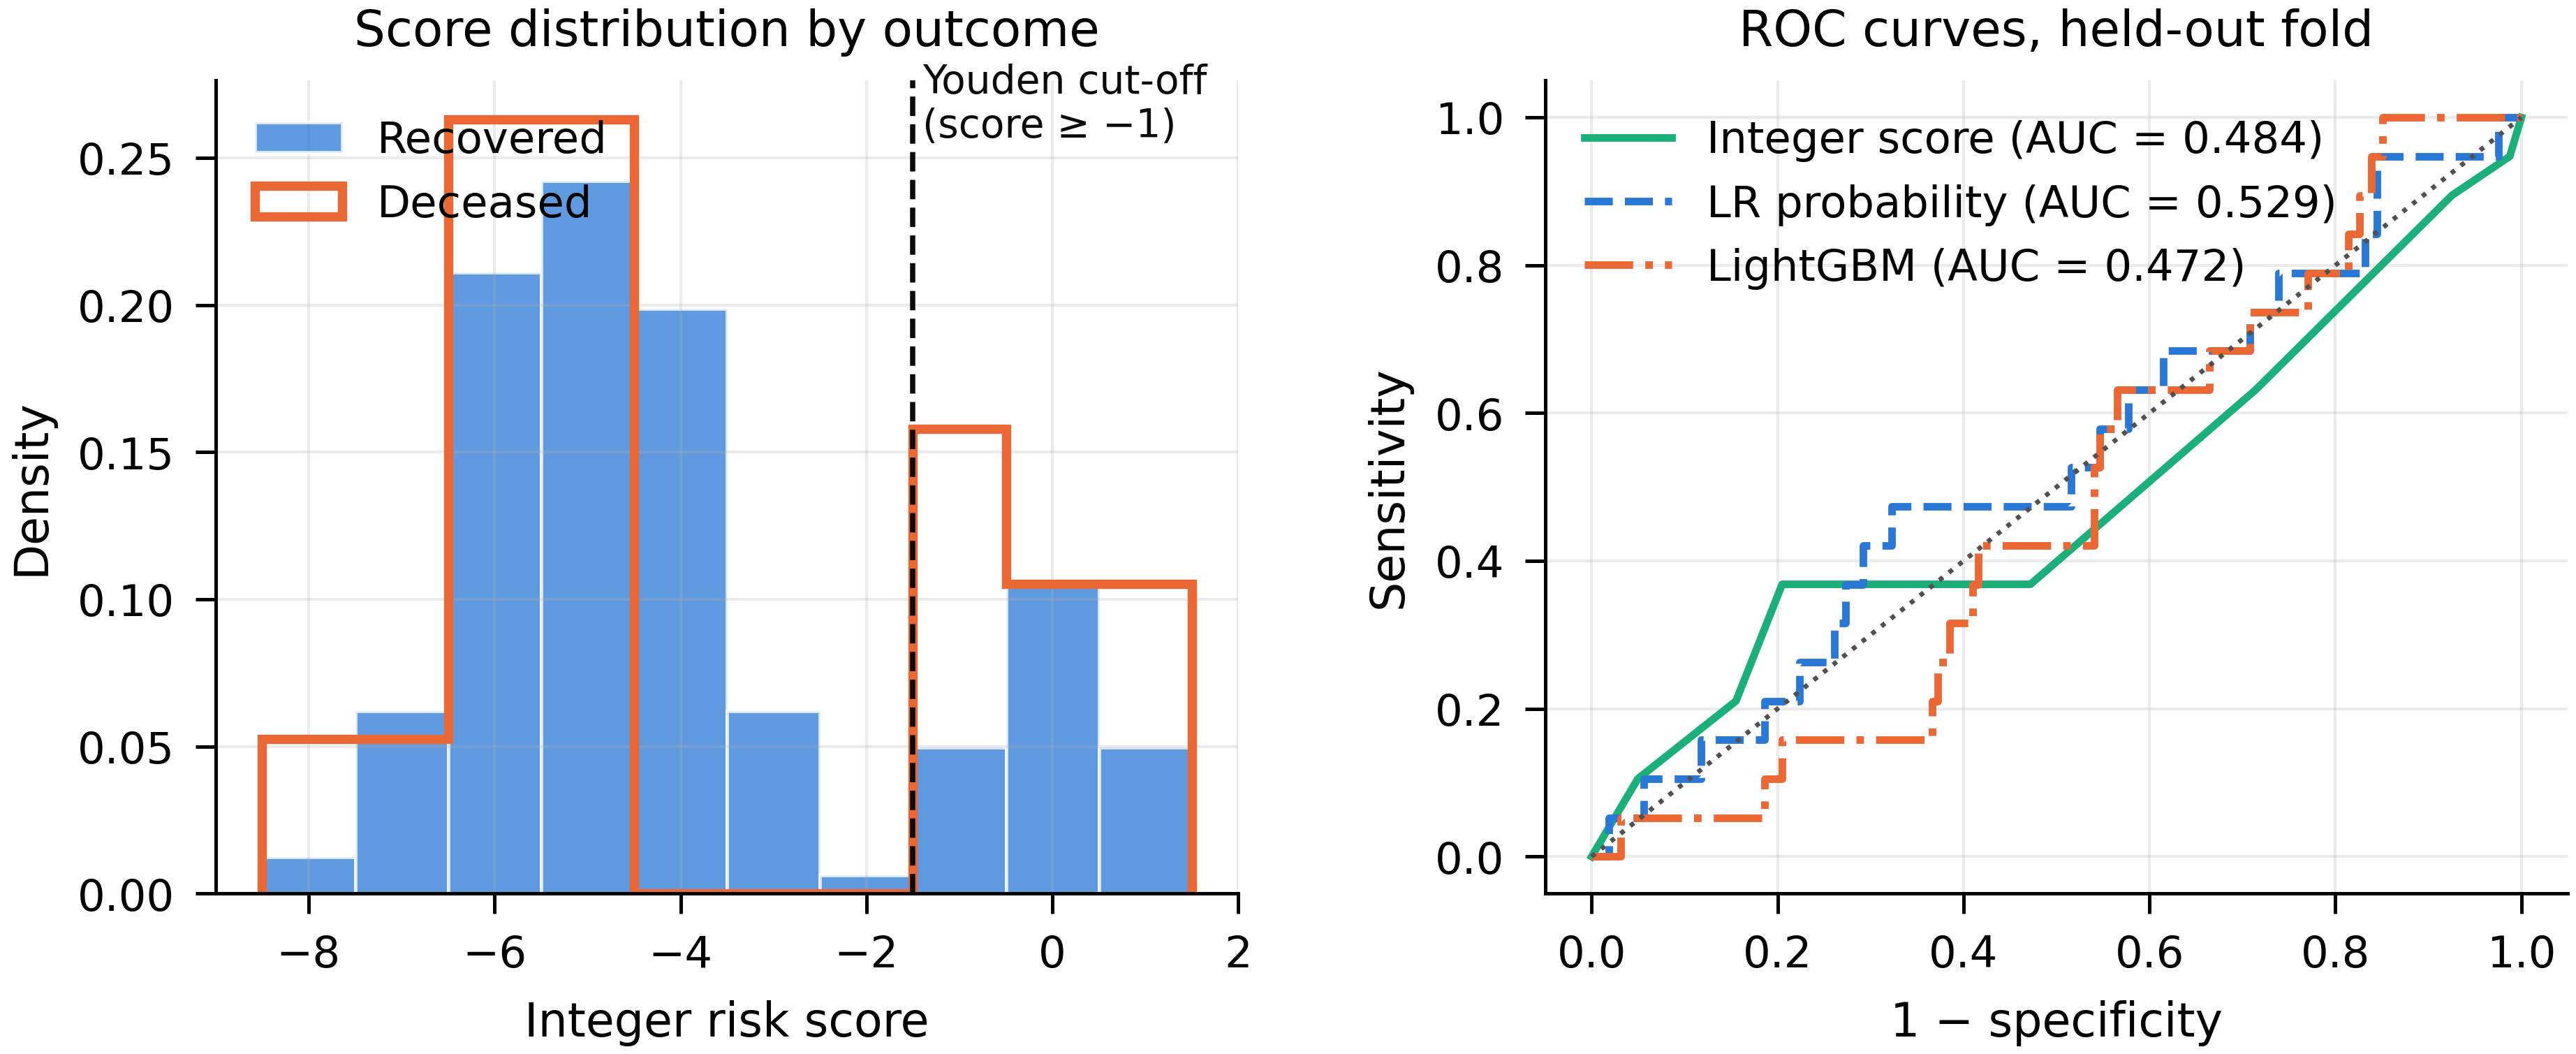

In [10]:
%run src/figures.py
from IPython.display import Image, display
import glob
for f in sorted(glob.glob('figures/*.png')):
    print(f); display(Image(filename=f, width=700))

## 8. Consistency checks

In [11]:
!{sys.executable} -m pytest -q tests

......                                                                   [100%]
6 passed in 1.82s
